# LMM — Sex classification, Upper Third Molar (Validation dataset)

- **Section A (MD)** — Mesiodistal width (`width_mm`)
- **Section B (TL)** — Total length/height (`height_mm`)

**selecte age group:** fix the condition `Age(year)` — Group 1 (14–17), Group 2 (18–25), or All (14–25, default)

In [8]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [9]:
%%R
install.packages(c("dplyr", "ggplot2", "lme4", "lmerTest", "performance", "readr"),
                  repos = "https://cloud.r-project.org", quiet = TRUE)

## 1. Load and prepare data

In [10]:
%%R
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(performance)
library(readr)

# Age sub-groups available in this dataset:
#   Group 1 : Age 14-17  -> change filter below to >= 14 & <= 17
#   Group 2 : Age 18-25  -> change filter below to >= 18 & <= 25
#   All     : Age 14-25  -> current default

data_all <- read_csv("data/sex_upper_third_molar_validation.csv")

# Age filter -- adjust bounds to select sub-group
data <- subset(data_all, `Age(year)` >= 14 & `Age(year)` <= 25)

# Factor encoding
data$patient_id <- as.factor(data$patient_id)
data$Gender     <- as.factor(data$Gender)   # "F" / "M"

cat("Observations :", nrow(data), "\n")
cat("Patients     :", n_distinct(data$patient_id), "\n")

Rows: 4638 Columns: 30
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): tagName, Filename, Gender, Folder_type, Folder_name, Path_Name, Ge...
dbl (21): left, top, width, height, Rleft, Rtop, Rwidth, Rheight, x_center, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Observations : 3181 
Patients     : 1741 


## 2. Data checks

In [11]:
%%R
# Check for patients with inconsistent sex labels
patient_sex <- data %>%
  group_by(patient_id) %>%
  summarise(n_sex      = n_distinct(Gender),
            sex_values = paste(unique(Gender), collapse = "/")) %>%
  filter(n_sex > 1)

cat("Patients with conflicting sex labels:", nrow(patient_sex), "\n")
if (nrow(patient_sex) > 0) print(patient_sex)

# Correlation between MD and TL (check before running each section)
cat("Correlation MD vs TL:", cor(data$width_mm, data$height_mm), "\n")

Patients with conflicting sex labels: 4 
# A tibble: 4 × 3
  patient_id n_sex sex_values
  <fct>      <int> <chr>     
1 B348.jpg       2 M/F       
2 B349.jpg       2 M/F       
3 B350.jpg       2 M/F       
4 B351.jpg       2 M/F       
Correlation MD vs TL: -0.08238522 


## SECTION A — Mesiodistal width (MD)
Outcome variable: `width_mm`

### 3A. Descriptive statistics

%%R
summary_table_MD <- data %>%
  group_by(Gender) %>%
  summarise(
    n_patients = n_distinct(patient_id),
    n_obs      = n(),
    mean       = round(mean(width_mm), 2),
    sd         = round(sd(width_mm), 2),
    min        = round(min(width_mm), 2),
    max        = round(max(width_mm), 2)
  )
print(summary_table_MD)

### 4A. Fit LMM — MD

In [12]:
%%R
model_MD <- lmer(width_mm ~ Gender + (1 | patient_id),
                 data = data)
summary(model_MD)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: width_mm ~ Gender + (1 | patient_id)
   Data: data

REML criterion at convergence: 14254.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.5368 -0.5386 -0.0827  0.4544  5.1228 

Random effects:
 Groups     Name        Variance Std.Dev.
 patient_id (Intercept) 2.587    1.608   
 Residual               3.146    1.774   
Number of obs: 3181, groups:  patient_id, 1741

Fixed effects:
              Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)   14.10868    0.07028 1747.88858  200.75   <2e-16 ***
GenderM       -0.06447    0.09923 1819.04567   -0.65    0.516    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
        (Intr)
GenderM -0.700


### 5A. Assumption checks — MD

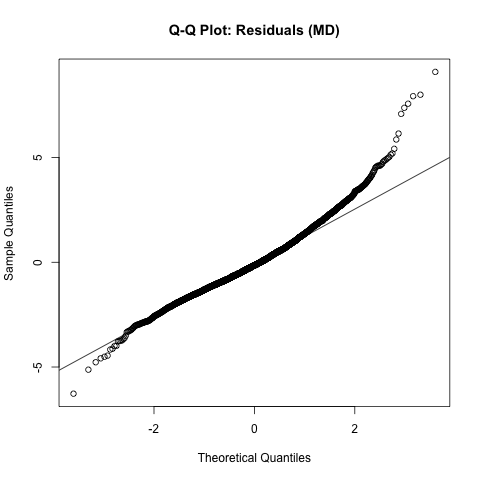

In [13]:
%%R
res_MD <- resid(model_MD)

qqnorm(res_MD, main = "Q-Q Plot: Residuals (MD)")
qqline(res_MD)

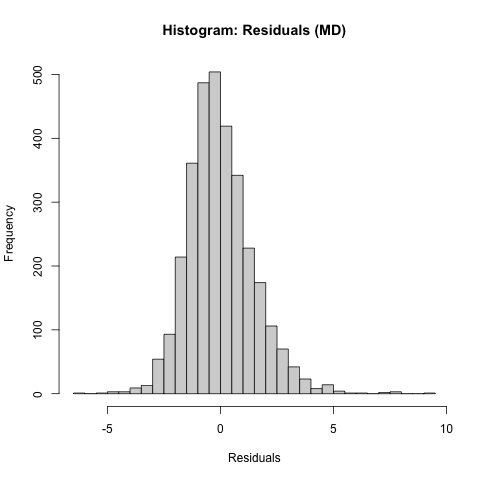

In [14]:
%%R
hist(res_MD, breaks = 30, main = "Histogram: Residuals (MD)", xlab = "Residuals")

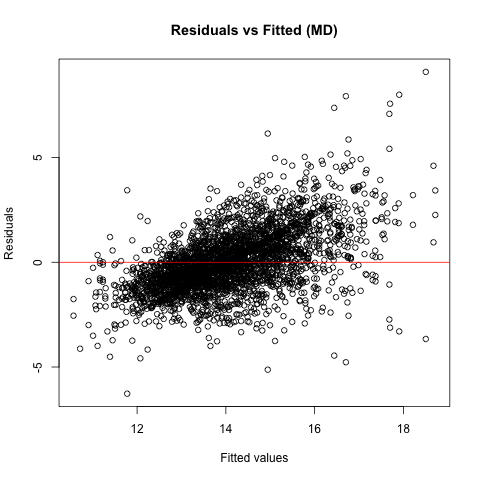

In [15]:
%%R
plot(fitted(model_MD), res_MD,
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted (MD)")
abline(h = 0, col = "red")

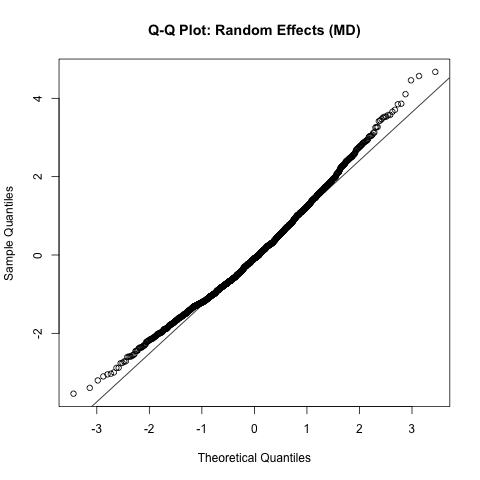

In [16]:
%%R
ranef_MD <- ranef(model_MD)$patient_id[, 1]
qqnorm(ranef_MD, main = "Q-Q Plot: Random Effects (MD)")
qqline(ranef_MD)

### 6A. Inference — MD

In [17]:
%%R
anova(model_MD)

Type III Analysis of Variance Table with Satterthwaite's method
       Sum Sq Mean Sq NumDF DenDF F value Pr(>F)
Gender 1.3279  1.3279     1  1819  0.4221  0.516


In [18]:
%%R
newdata_MD <- data.frame(Gender = c("F", "M"))
newdata_MD$predicted <- predict(model_MD, newdata_MD, re.form = NA)
print(newdata_MD)

  Gender predicted
1      F  14.10868
2      M  14.04422


In [19]:
%%R
r2(model_MD)

# R2 for Mixed Models

  Conditional R2: 0.451
     Marginal R2: 0.000


## SECTION B — Total length/height (TL)
Outcome variable: `height_mm`

### 3B. Descriptive statistics

In [20]:
%%R
summary_table_TL <- data %>%
  group_by(Gender) %>%
  summarise(
    n_patients = n_distinct(patient_id),
    n_obs      = n(),
    mean       = round(mean(height_mm), 2),
    sd         = round(sd(height_mm), 2),
    min        = round(min(height_mm), 2),
    max        = round(max(height_mm), 2)
  )
print(summary_table_TL)

# A tibble: 2 × 7
  Gender n_patients n_obs  mean    sd   min   max
  <fct>       <int> <int> <dbl> <dbl> <dbl> <dbl>
1 F             872  1615  16.6  2.97  7.21  26.1
2 M             873  1566  17.8  2.88  7.1   27.1


### 4B. Fit LMM — TL

In [21]:
%%R
model_TL <- lmer(height_mm ~ Gender + (1 | patient_id),
                 data = data)
summary(model_TL)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: height_mm ~ Gender + (1 | patient_id)
   Data: data

REML criterion at convergence: 15040.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.2102 -0.4601 -0.0071  0.4568  3.7665 

Random effects:
 Groups     Name        Variance Std.Dev.
 patient_id (Intercept) 5.776    2.403   
 Residual               2.880    1.697   
Number of obs: 3181, groups:  patient_id, 1741

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 1.666e+01  9.129e-02 1.776e+03 182.497   <2e-16 ***
GenderM     1.126e+00  1.280e-01 1.878e+03   8.796   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
        (Intr)
GenderM -0.698


### 5B. Assumption checks — TL

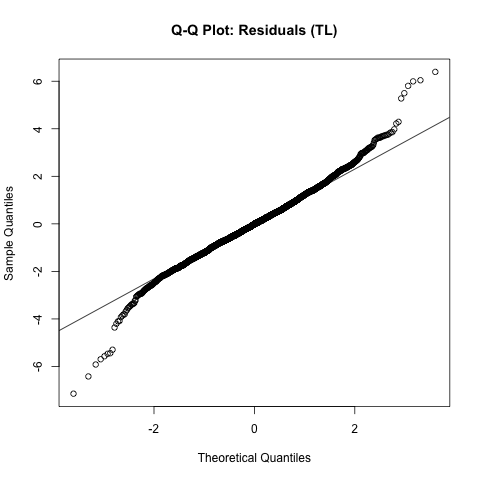

In [22]:
%%R
res_TL <- resid(model_TL)

qqnorm(res_TL, main = "Q-Q Plot: Residuals (TL)")
qqline(res_TL)

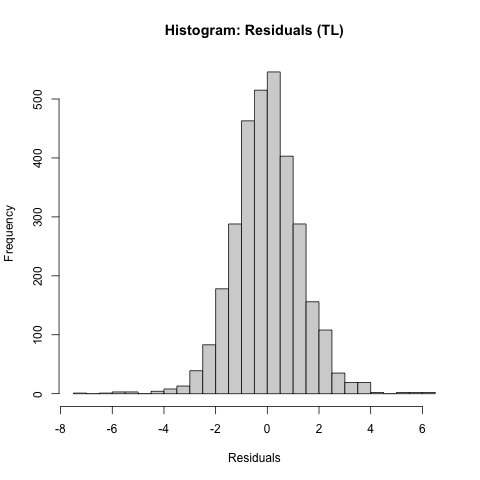

In [23]:
%%R
hist(res_TL, breaks = 30, main = "Histogram: Residuals (TL)", xlab = "Residuals")

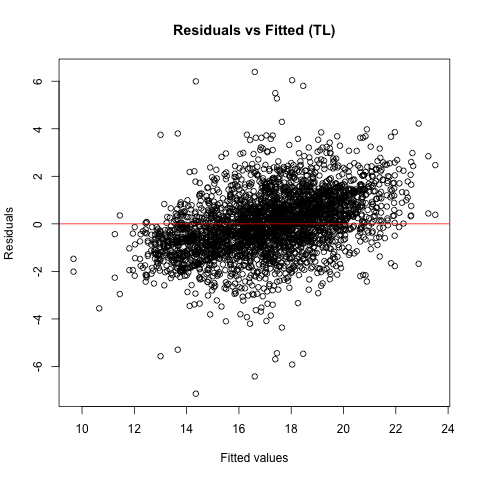

In [24]:
%%R
plot(fitted(model_TL), res_TL,
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted (TL)")
abline(h = 0, col = "red")

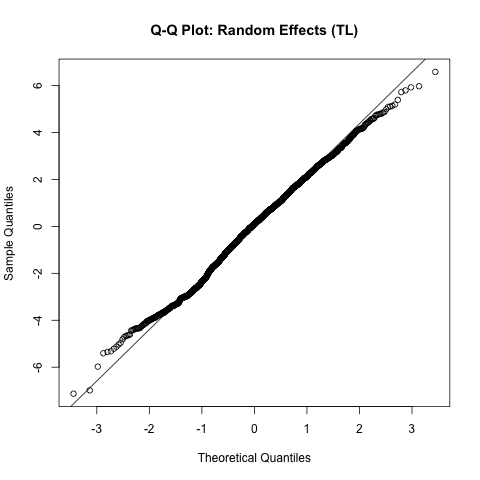

In [25]:
%%R
ranef_TL <- ranef(model_TL)$patient_id[, 1]
qqnorm(ranef_TL, main = "Q-Q Plot: Random Effects (TL)")
qqline(ranef_TL)

### 6B. Inference — TL

In [26]:
%%R
anova(model_TL)

Type III Analysis of Variance Table with Satterthwaite's method
       Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
Gender 222.85  222.85     1 1878.4  77.377 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [27]:
%%R
newdata_TL <- data.frame(Gender = c("F", "M"))
newdata_TL$predicted <- predict(model_TL, newdata_TL, re.form = NA)
print(newdata_TL)

  Gender predicted
1      F  16.66008
2      M  17.78565


In [28]:
%%R
r2(model_TL)

# R2 for Mixed Models

  Conditional R2: 0.679
     Marginal R2: 0.035
